# CAPSTONE PROJECT Analyzing Electric Vehicle Adoption and Identifying Key Market Drivers Using Machine Learning Techniques on Large-Scale Vehicle Registration Data

## Importing necessary libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importing the dataset

In [4]:
import pandas as pd
file_path = "/content/drive/MyDrive/Colab_Notebooks/AIML/Electric_Vehicle_Population_Data_20260410.csv"
df = pd.read_csv(file_path)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [6]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

In [8]:
df.isnull().sum()

,0
VIN (1-10),0
County,24
City,24
State,0
Postal Code,24
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### Shape of the Dataset

In [9]:
print('Total number of rows in the dataset:',df.shape[0])
print('Total number of columns in the dataset:',df.shape[1])

Total number of rows in the dataset: 279780
Total number of columns in the dataset: 16


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,279756.0,9.817611e+04,2.577398e+03,1.030000e+03,9.805200e+04,9.813300e+04,9.838200e+04,9.951700e+04
Model Year,279780.0,2.022074e+03,3.059852e+00,1.999000e+03,2.021000e+03,2.023000e+03,2.024000e+03,2.027000e+03
Electric Range,279769.0,3.917226e+01,7.823036e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,3.370000e+02
Legislative District,279080.0,2.882784e+01,1.490813e+01,1.000000e+00,1.700000e+01,3.200000e+01,4.200000e+01,4.900000e+01
DOL Vehicle ID,279780.0,2.462994e+08,6.346205e+07,4.385000e+03,2.213867e+08,2.629453e+08,2.790832e+08,4.791150e+08
2020 Census Tract,279756.0,5.297189e+10,1.636194e+09,1.001020e+09,5.303301e+10,5.303303e+10,5.305394e+10,6.601095e+10


### Checking for duplicates:

In [11]:
if df.duplicated().sum()==0:
    print('There are no duplicate rows in the dataset.')
else:
    print('Total number of duplicate rows in the dataset :',df.duplicated().sum())

There are no duplicate rows in the dataset.


**Handling Missing Values**

In [12]:
# Fill numeric column safely
df['Electric Range'] = df['Electric Range'].fillna(0)

# Fill location-related columns using forward fill
cols_to_fill = ['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract']
df[cols_to_fill] = df[cols_to_fill].fillna(method='ffill')

In [13]:
df.isnull().sum()

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### Summary of the data

#### a) Categorical columns:

In [14]:
cat = df.select_dtypes(include=['object']).columns
df[cat].describe().T

,count,unique,top,freq
VIN (1-10),279780,17072,7SAYGDEE7P,1187
County,279780,253,King,138145
City,279780,894,Seattle,43252
State,279780,52,WA,279093
Make,279780,47,TESLA,114847
Model,279780,187,MODEL Y,60035
Electric Vehicle Type,279780,2,Battery Electric Vehicle (BEV),223884
Clean Alternative Fuel Vehicle (CAFV) Eligibility,279780,3,Eligibility unknown as battery range has not b...,177937
Vehicle Location,279671,1115,POINT (-122.13158 47.67858),6776
Electric Utility,279780,77,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),99581


#### b) Continuous numeric columns:

In [15]:
continuous = df.select_dtypes(include=['float64']).columns
df[continuous].describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,279780.0,9.817611e+04,2.577289e+03,1.030000e+03,9.805200e+04,9.813300e+04,9.838200e+04,9.951700e+04
Electric Range,279780.0,3.917072e+01,7.822920e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,3.370000e+02
Legislative District,279080.0,2.882784e+01,1.490813e+01,1.000000e+00,1.700000e+01,3.200000e+01,4.200000e+01,4.900000e+01
2020 Census Tract,279780.0,5.297189e+10,1.636124e+09,1.001020e+09,5.303301e+10,5.303303e+10,5.305394e+10,6.601095e+10


----

#EDA (Exploratory data analysis)

## a) Univariate analysis

#### Distribution of EV Types (BEV vs PHEV)

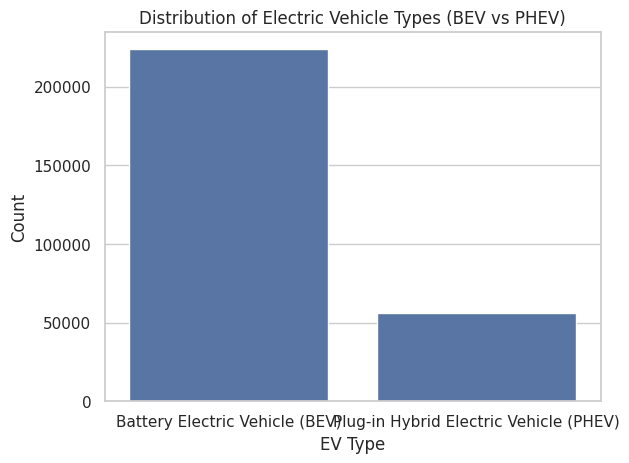

In [16]:
# Purpose: To understand the distribution of different types of electric vehicles

sns.countplot(data=df, x='Electric Vehicle Type')
plt.title("Distribution of Electric Vehicle Types (BEV vs PHEV)")
plt.xlabel("EV Type")
plt.ylabel("Count")
plt.show()

#### Distribution of Electric Vehicles by Model Year

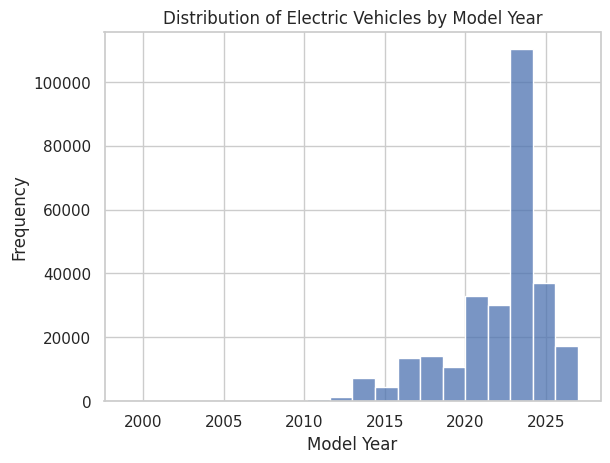

In [17]:
# Purpose: To analyze the trend of EV adoption over different years

sns.histplot(df['Model Year'], bins=20)
plt.title("Distribution of Electric Vehicles by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Frequency")
plt.show()

### 3. Distribution of Electric Vehicle Range

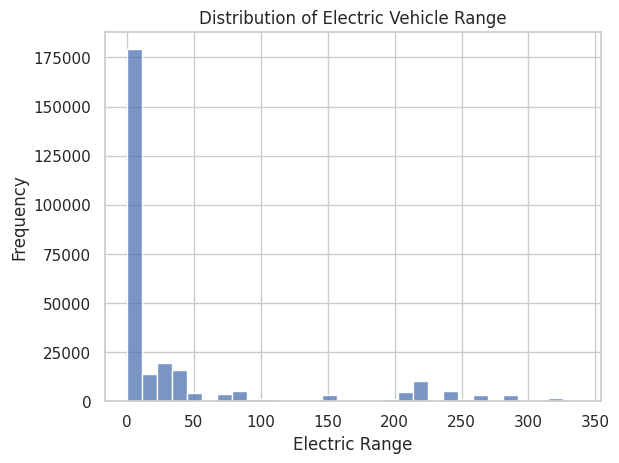

In [18]:
# Purpose: To understand the variation in electric driving range among EVs

sns.histplot(df['Electric Range'], bins=30)
plt.title("Distribution of Electric Vehicle Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")
plt.show()

### 4. Distribution of Top EV Manufacturers

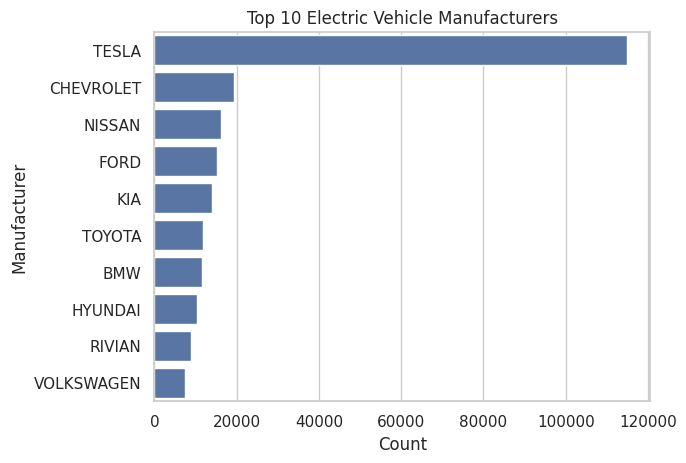

In [19]:
# Purpose: To identify the most common EV manufacturers in the dataset

top_makes = df['Make'].value_counts().head(10)

sns.barplot(x=top_makes.values, y=top_makes.index)
plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.show()

## B) BIVARIATE ANALYSIS

1. EV Type vs Manufacturer

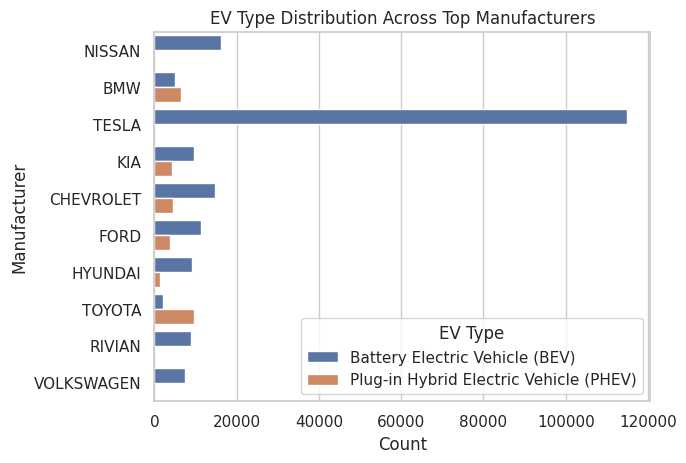

In [20]:
# Purpose: To analyze how EV types (BEV vs PHEV) vary across different manufacturers

top_makes = df['Make'].value_counts().head(10).index

sns.countplot(data=df[df['Make'].isin(top_makes)],
              y='Make',
              hue='Electric Vehicle Type')

plt.title("EV Type Distribution Across Top Manufacturers")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.legend(title="EV Type")
plt.show()

####2. EV Type vs Model Year:

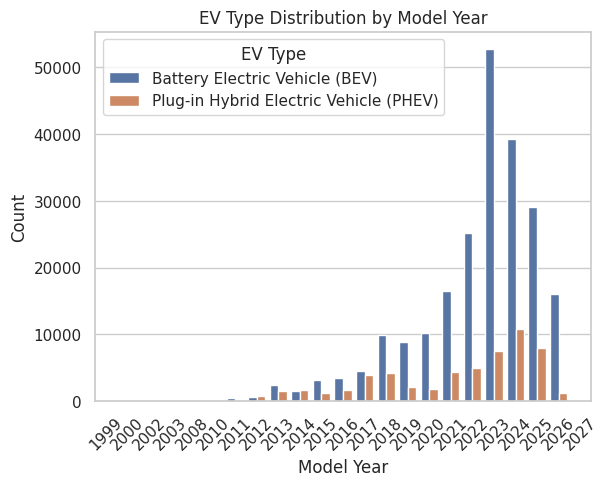

In [21]:
# Purpose: To analyze how EV type distribution changes over different model years

sns.countplot(data=df,
              x='Model Year',
              hue='Electric Vehicle Type')

plt.title("EV Type Distribution by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="EV Type")
plt.show()

### 3. Electric Range vs EV Type

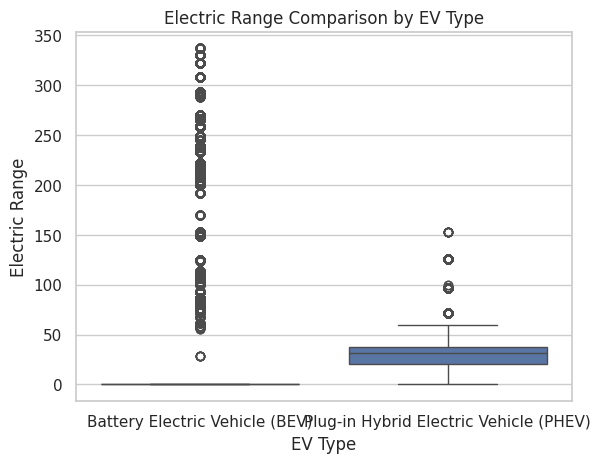

In [22]:
# Purpose: To compare electric range across different EV types

sns.boxplot(data=df,
            x='Electric Vehicle Type',
            y='Electric Range')

plt.title("Electric Range Comparison by EV Type")
plt.xlabel("EV Type")
plt.ylabel("Electric Range")
plt.show()

## Multivariate analysis

### EV Type vs Manufacturer vs Electric Range

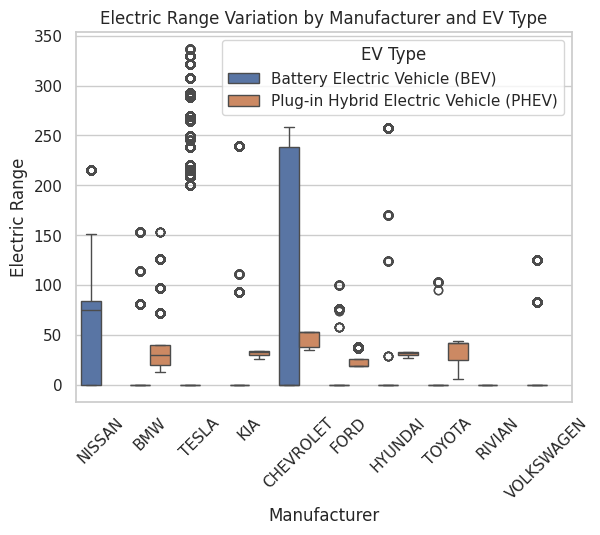

In [23]:
# Purpose: To analyze relationship between EV type, manufacturer, and electric range

top_makes = df['Make'].value_counts().head(10).index

subset = df[df['Make'].isin(top_makes)]

sns.boxplot(data=subset,
            x='Make',
            y='Electric Range',
            hue='Electric Vehicle Type')

plt.title("Electric Range Variation by Manufacturer and EV Type")
plt.xlabel("Manufacturer")
plt.ylabel("Electric Range")
plt.xticks(rotation=45)
plt.legend(title="EV Type")
plt.show()

### Correlation Heatmap of Numerical Features (Model Year, Electric Range, Legislative District)

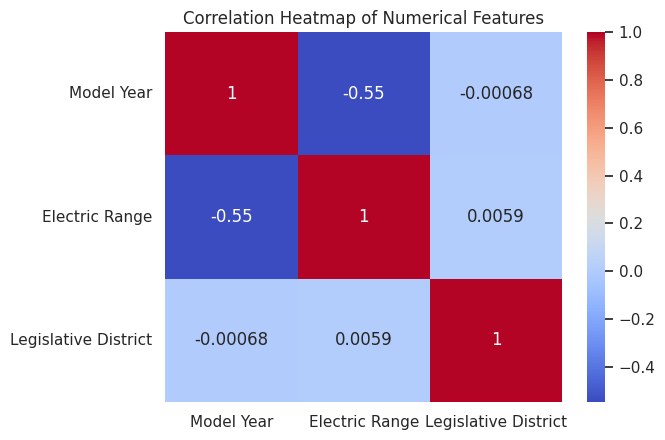

In [24]:
import seaborn as sns

numeric_cols = ['Model Year', 'Electric Range', 'Legislative District']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()